# Image Classification with a Convolutional Neural Network

In this notebook we'll train a small CNN to distinguish between two classes of images from CIFAR-10: **cars** and **trucks**. We'll also see how to "stand on the shoulders of giants" by using the convolutional layers of a pretrained model.

**Note**: in addition to PyTorch, you'll need to install the `torchvision` package to run this notebook. It provides tools for for computer vision; we'll mostly use it to provide the data.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

## Step 1) Load the Data

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) contains 60,000 tiny (32 x 32) color images in 10 classes. PyTorch's `torchvision` can download it for us automatically.

In [2]:
train_set = CIFAR10(root='./data', train=True, download=True)
test_set = CIFAR10(root='./data', train=False, download=True)

print(f"Training images: {len(train_set)}")
print(f"Test images:     {len(test_set)}")
print(f"Classes:         {train_set.classes}")

Training images: 50000
Test images:     10000
Classes:         ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


We only want two classes -- cars (label 1) and trucks (label 9) -- so we'll filter them out. We also convert the images to grayscale to keep things simple: our CNN will have a single input channel instead of three.

In [3]:
def extract_two_classes(dataset, class_a, class_b):
    """Pull out two classes from a CIFAR-10 dataset and return grayscale images + binary labels."""
    images = np.array(dataset.data, dtype=np.float32)          # (N, 32, 32, 3)
    labels = np.array(dataset.targets)

    mask = (labels == class_a) | (labels == class_b)
    images = images[mask]
    labels = (labels[mask] == class_b).astype(np.float32)      # 0 = class_a, 1 = class_b

    # convert to grayscale: channel-wise norm (same as Euclidean norm of the RGB vector)
    gray = np.sqrt((images ** 2).sum(axis=-1, keepdims=True))  # (N, 32, 32, 1)

    # PyTorch expects (N, C, H, W)
    gray = gray.transpose(0, 3, 1, 2)                         # (N, 1, 32, 32)

    X = torch.tensor(gray)
    y = torch.tensor(labels).unsqueeze(1)                      # (N, 1)
    return X, y

CAR, TRUCK = 1, 9

X_train, y_train = extract_two_classes(train_set, CAR, TRUCK)
X_test, y_test   = extract_two_classes(test_set, CAR, TRUCK)

print(f"Training set: {X_train.shape}  (cars: {(y_train == 0).sum().item()}, trucks: {(y_train == 1).sum().item()})")
print(f"Test set:     {X_test.shape}")

Training set: torch.Size([10000, 1, 32, 32])  (cars: 5000, trucks: 5000)
Test set:     torch.Size([2000, 1, 32, 32])


Let's look at a few examples to make sure everything is reasonable.

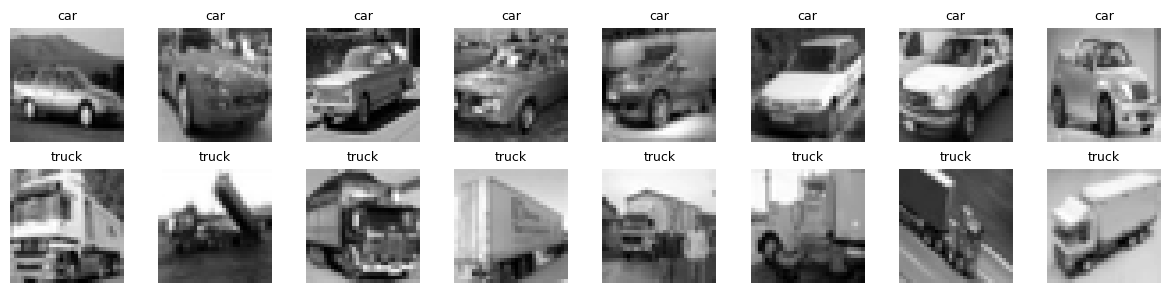

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
names = ['car', 'truck']
for cls, row in enumerate(axes):
    idxs = (y_train.squeeze() == cls).nonzero().squeeze()
    for ax, i in zip(row, idxs[:8]):
        ax.imshow(X_train[i, 0], cmap='gray')
        ax.set_title(names[cls], fontsize=9)
        ax.axis('off')
plt.tight_layout()

## Step 2) Define the Model

Next, we must decide the architecture of our CNN. Any CNN will start with one or more convolutional layers, followed by zero or more fully-connected hidden layers and one output layer. How many layers to use is up to us, and is largely determined by trial-and-error. In this case, we don't have a massive data set, so we'll aim for a smaller network with fewer parameters.

It isn't just the number of layers we need to decide on, either. In the convolutional layers, we must determine *filter sizes*. We must decide whether or not to use pooling, and/or batch normalization, etc.

Here is a network architecture that works well. First, we'll use three convolutional "blocks", each consisting of:

- A **convolution** (`Conv2d`);
- **Batch normalization** (`BatchNorm2d`); followed by
- A **ReLU** activation.

The first two blocks also include **max-pooling** to reduce the spatial dimensions.

After the convolutional layers, we flatten the feature maps into a vector and pass them through two linear (fully-connected) layers. The final sigmoid squashes the output to a probability between 0 and 1.

The size of the tensors passed between each module is shown below:

```
Input (1, 32, 32)
  -> Conv(32 filters, 7x7) -> BN -> ReLU -> MaxPool(2x2)    # (32, 13, 13)
  -> Conv(64 filters, 5x5) -> BN -> ReLU -> MaxPool(2x2)    # (64, 4, 4)  -> (64, 2, 2)
  -> Conv(64 filters, 3x3) -> BN -> ReLU                    # (64, 2, 2)
  -> Flatten                                                  # (256,)
  -> Linear(256 -> 64) -> ReLU
  -> Linear(64 -> 1) -> Sigmoid
```

In [5]:
model = nn.Sequential(
    # --- block 1 ---
    nn.Conv2d(1, 32, kernel_size=7),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # --- block 2 ---
    nn.Conv2d(32, 64, kernel_size=5),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # --- block 3 ---
    nn.Conv2d(64, 64, kernel_size=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    # --- classifier ---
    nn.Flatten(),
    nn.Linear(64 * 2 * 2, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid(),
)

model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): Linear(in_features=256, out_features=64, bias=True)
  (13): ReLU()
  (14): Linear(in_features=64, out_features=1, bias=True)
  (15): Sigmoid()
)

## Step 3) Choose a Loss and Optimizer

Since this is binary classification, we use cross-entropy loss, as discussed in lecture. We'll use Adam as the optimizer, but mini-batch SGD would work as well.

**Note**: try simple gradient descent instead of the above. You can do this by choosing SGD as the optimizer, and setting the batch size equal to the number of training examples. What happens? Why?

In [6]:
len(X_train)

10000

In [7]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

## Step 4) Train

Now we run the training loop. There is one small new aspect to the below code: `model.train()` and `model.eval()`. Somewhat confusingly, `model.train()` does *not* train the model (and `model.eval()` doesn't evaluate it). Rather, they toggle the model's *mode*. This is done because certain parts of the architecture behave differently at train time and test time. In this case, it's batch normalization: during training, the batch norm layer computes means and standard deviations from the training data and stores these; during test time, it uses the stored statistics.

In [8]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=512, shuffle=True)

for epoch in range(30):
    # --- training ---
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct += ((pred > 0.5) == y_batch).sum().item()
        n += len(y_batch)

    # --- evaluation ---
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_acc = ((test_pred > 0.5) == y_test).float().mean().item()

    print(f"Epoch {epoch+1:2d}/30  "
          f"loss={total_loss/n:.4f}  "
          f"train_acc={correct/n:.3f}  "
          f"test_acc={test_acc:.3f}")

Epoch  1/30  loss=0.5726  train_acc=0.700  test_acc=0.757
Epoch  2/30  loss=0.4160  train_acc=0.813  test_acc=0.822
Epoch  3/30  loss=0.3382  train_acc=0.859  test_acc=0.632
Epoch  4/30  loss=0.2997  train_acc=0.873  test_acc=0.827
Epoch  5/30  loss=0.2273  train_acc=0.910  test_acc=0.659
Epoch  6/30  loss=0.1874  train_acc=0.928  test_acc=0.812
Epoch  7/30  loss=0.1542  train_acc=0.941  test_acc=0.823
Epoch  8/30  loss=0.1206  train_acc=0.956  test_acc=0.829
Epoch  9/30  loss=0.0828  train_acc=0.973  test_acc=0.641
Epoch 10/30  loss=0.0576  train_acc=0.980  test_acc=0.752
Epoch 11/30  loss=0.0502  train_acc=0.983  test_acc=0.827
Epoch 12/30  loss=0.0330  train_acc=0.990  test_acc=0.840
Epoch 13/30  loss=0.0196  train_acc=0.995  test_acc=0.864
Epoch 14/30  loss=0.0101  train_acc=0.998  test_acc=0.872
Epoch 15/30  loss=0.0053  train_acc=1.000  test_acc=0.858
Epoch 16/30  loss=0.0030  train_acc=1.000  test_acc=0.858
Epoch 17/30  loss=0.0016  train_acc=1.000  test_acc=0.873
Epoch 18/30  l

In [9]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)

test_acc = ((test_pred > 0.5) == y_test).float().mean().item()
print(f"Test accuracy: {test_acc:.1%}")

Test accuracy: 87.2%


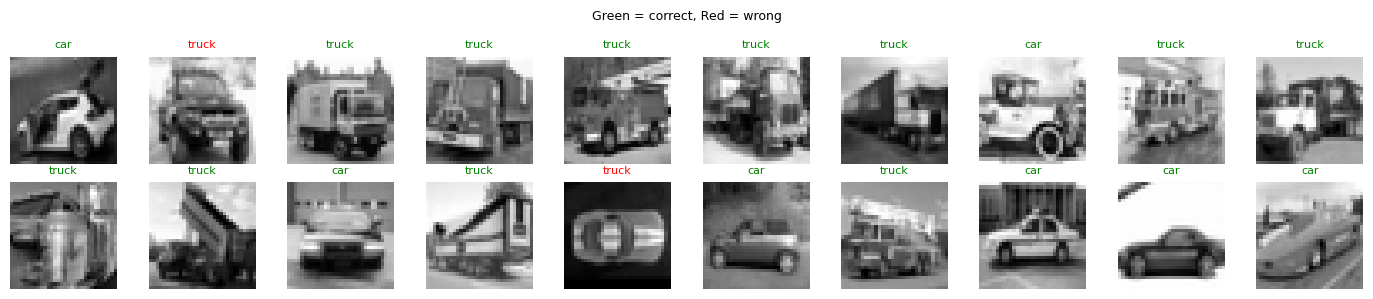

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
names = ['car', 'truck']
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i, 0], cmap='gray')
    pred_label = names[int(test_pred[i] > 0.5)]
    true_label = names[int(y_test[i])]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"{pred_label}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle("Green = correct, Red = wrong", fontsize=9)
plt.tight_layout()

## Step 5) Standing on the Shoulders of Giants

Our from-scratch CNN reached about 88% test accuracy. Can we do better without designing a bigger model ourselves?

**Transfer learning** lets us reuse a model that was already trained on a large dataset (like ImageNet, which has 1.2 million images in 1,000 classes). The idea: the convolutional layers of such a model have already learned to detect useful visual features — edges, textures, shapes — that transfer well to new tasks.

The recipe is simple:

1. Load a pretrained model (we'll use **ResNet-18**).
2. **Freeze** all the convolutional layers so their weights don't change.
3. **Replace** the final classification layer with a new one for our task.
4. Train only the new layer.

There's one catch: ResNet-18 was trained on 224 × 224 RGB images, so we need to prepare our data accordingly — using color images (not grayscale) and resizing them.

**Speed trick**: since the convolutional layers are frozen, they always produce the same output for a given image. Instead of re-running every image through the entire network each epoch, we'll pre-compute the backbone features *once* and then train only the small classifier head on those feature vectors. This turns each epoch from minutes into milliseconds.

In [11]:
from torchvision import models, transforms

def extract_two_classes_rgb(dataset, class_a, class_b, transform):
    """Pull out two classes and return transformed RGB images + binary labels."""
    images = np.array(dataset.data)            # (N, 32, 32, 3), uint8
    labels = np.array(dataset.targets)

    mask = (labels == class_a) | (labels == class_b)
    images = images[mask]
    labels = (labels[mask] == class_b).astype(np.float32)

    X = torch.stack([transform(img) for img in images])
    y = torch.tensor(labels).unsqueeze(1)
    return X, y

# ResNet expects ImageNet-normalized 224x224 RGB input
resnet_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

X_train_rgb, y_train_rgb = extract_two_classes_rgb(train_set, CAR, TRUCK, resnet_transform)
X_test_rgb, y_test_rgb   = extract_two_classes_rgb(test_set, CAR, TRUCK, resnet_transform)

print(f"Training: {X_train_rgb.shape}")
print(f"Test:     {X_test_rgb.shape}")

Training: torch.Size([10000, 3, 224, 224])
Test:     torch.Size([2000, 3, 224, 224])


We can also get a speedup by using the GPU. To do this, we either need CUDA or MPS (Apple's alternative). If neither is available, we'll use the CPU as a default:

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [13]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval()
resnet = resnet.to(device)

# extract the backbone (everything except the final FC layer)
backbone = nn.Sequential(*list(resnet.children())[:-1], nn.Flatten())

# pre-compute features for all images (this is the slow part — but we only do it once)
print("Extracting features...", end=" ")
with torch.no_grad():
    feats_train = torch.cat([backbone(X_train_rgb[i:i+128].to(device)).cpu()
                             for i in range(0, len(X_train_rgb), 128)])
    feats_test  = torch.cat([backbone(X_test_rgb[i:i+128].to(device)).cpu()
                             for i in range(0, len(X_test_rgb), 128)])
print(f"Feature vectors: {feats_train.shape}  (each image -> {feats_train.shape[1]}-d vector)")

Extracting features... Feature vectors: torch.Size([10000, 512])  (each image -> 512-d vector)


Now we'll train a simple classifier on top of the resnet features:

In [14]:
# tiny classifier: just a single linear layer on top of the frozen features
classifier = nn.Sequential(
    nn.Linear(512, 1),
    nn.Sigmoid(),
)

clf_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
clf_loss_fn = nn.BCELoss()

feat_loader = DataLoader(TensorDataset(feats_train, y_train_rgb), batch_size=512, shuffle=True)

for epoch in range(30):
    classifier.train()
    total_loss, correct, n = 0.0, 0, 0
    for f_batch, y_batch in feat_loader:
        pred = classifier(f_batch)
        loss = clf_loss_fn(pred, y_batch)

        clf_optimizer.zero_grad()
        loss.backward()
        clf_optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct += ((pred > 0.5) == y_batch).sum().item()
        n += len(y_batch)

    classifier.eval()
    with torch.no_grad():
        test_pred_resnet = classifier(feats_test)
        test_acc = ((test_pred_resnet > 0.5) == y_test_rgb).float().mean().item()

    print(f"Epoch {epoch+1:2d}/30  "
          f"loss={total_loss/n:.4f}  "
          f"train_acc={correct/n:.3f}  "
          f"test_acc={test_acc:.3f}")

Epoch  1/30  loss=0.5215  train_acc=0.829  test_acc=0.905
Epoch  2/30  loss=0.3440  train_acc=0.921  test_acc=0.924
Epoch  3/30  loss=0.2666  train_acc=0.928  test_acc=0.930
Epoch  4/30  loss=0.2279  train_acc=0.935  test_acc=0.934
Epoch  5/30  loss=0.2050  train_acc=0.938  test_acc=0.939
Epoch  6/30  loss=0.1894  train_acc=0.941  test_acc=0.942
Epoch  7/30  loss=0.1777  train_acc=0.943  test_acc=0.943
Epoch  8/30  loss=0.1686  train_acc=0.947  test_acc=0.945
Epoch  9/30  loss=0.1617  train_acc=0.948  test_acc=0.946
Epoch 10/30  loss=0.1554  train_acc=0.949  test_acc=0.947
Epoch 11/30  loss=0.1506  train_acc=0.949  test_acc=0.947
Epoch 12/30  loss=0.1466  train_acc=0.951  test_acc=0.947
Epoch 13/30  loss=0.1428  train_acc=0.951  test_acc=0.947
Epoch 14/30  loss=0.1398  train_acc=0.952  test_acc=0.946
Epoch 15/30  loss=0.1364  train_acc=0.952  test_acc=0.948
Epoch 16/30  loss=0.1342  train_acc=0.953  test_acc=0.946
Epoch 17/30  loss=0.1320  train_acc=0.954  test_acc=0.947
Epoch 18/30  l

We should see a pretty significant improvement to the classification accuracy:

In [15]:
classifier.eval()
with torch.no_grad():
    resnet_acc = ((classifier(feats_test) > 0.5) == y_test_rgb).float().mean().item()

# recompute from-scratch accuracy for comparison
model.eval()
with torch.no_grad():
    cnn_acc = ((model(X_test) > 0.5) == y_test).float().mean().item()

print(f"From-scratch CNN test accuracy: {cnn_acc:.1%}")
print(f"Pretrained ResNet test accuracy: {resnet_acc:.1%}")

From-scratch CNN test accuracy: 87.2%
Pretrained ResNet test accuracy: 95.1%


However, the classification accuracy is still not 100%. Why is this? Take a look at the sample CIFAR-100 images again

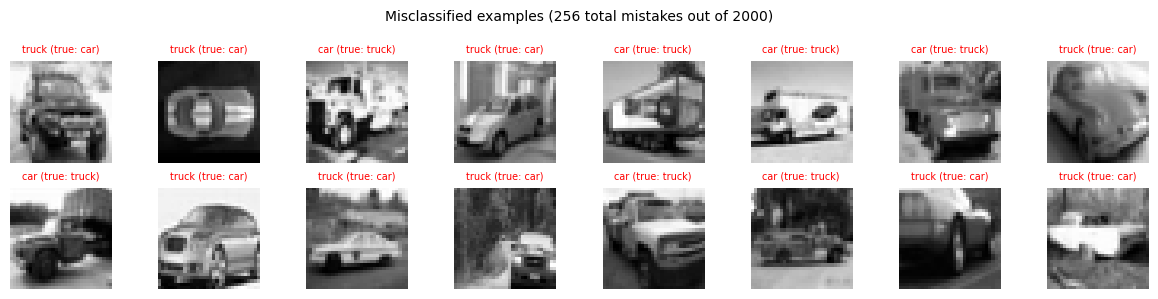

In [16]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)

pred_labels = (test_pred > 0.5).float()
wrong = (pred_labels != y_test).squeeze().nonzero().squeeze()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
names = ['car', 'truck']
for ax, i in zip(axes.flat, wrong[:16]):
    ax.imshow(X_test[i, 0], cmap='gray')
    ax.set_title(f"{names[int(pred_labels[i])]} (true: {names[int(y_test[i])]})", fontsize=7, color='red')
    ax.axis('off')
plt.suptitle(f"Misclassified examples ({len(wrong)} total mistakes out of {len(y_test)})", fontsize=10)
plt.tight_layout()

Some of these examples just look difficult. For example, the 3rd image in the top row is not clearly a truck, at least to my human eyes. But many of the others are clearer. We might expect a human to get closer to 100% test accuracy, so why isn't our deep learning model?

One reason might be that we need more learned parameters. You can try playing around with the "head" of the network (the layer that we added and trained). We've used only a single layer here, and so we've effectively done logistic regression on top of the resnet-18 features. We could try adding more hidden layers to learn a more complicated, non-linear pattern, but you might not find a big improvement by doing this.

Another possible reason is that the filters learned by resnet-18 are not a perfect match to this dataset. Remember: resnet-18 was trained on ImageNet, which is a different data set. Our data are grayscale, and not color (like ImageNet). We had to resize them to get them to be the same shape as the ImageNet data. It is possible that these subtle differences are behind most of the error. This is a general theme in transfer learning: when we learn on one data set and use that model (or some of that model) in another situation, there is a "distirbutional shift": the data in the new application doesn't look *exactly* like the data we've trained on, and so we might expect a performance hit. We can try to mitigate this by "fine tuning" some of the convolutional layers, as shown in the next section.

We also might be overfitting, and we should explore regularization techniques.

## Step 7) Fine-Tuning the Last Convolutional Layer

So far we've kept the entire ResNet backbone frozen and only trained the classifier head. But the pretrained features were learned on ImageNet — a very different dataset from CIFAR-10. By "unfreezing" the last convolutional block (`layer4`) and letting it adapt to our data, we allow the network to refine its high-level features for the car-vs-truck distinction.

The trade-off: we can no longer pre-compute backbone features, since the convolutional weights now change each epoch. Training will be slower, but we may get better accuracy.

We also use a "lower learning rate" for the unfrozen convolutional layer than for the fresh classifier head. This is important: the pretrained weights are already good, so we only want to nudge them gently.

In [17]:
# load a fresh pretrained ResNet-18
ft_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze everything
for param in ft_model.parameters():
    param.requires_grad = False

# unfreeze layer4 (the last convolutional block)
for param in ft_model.layer4.parameters():
    param.requires_grad = True

# replace the final FC layer with our binary classifier
ft_model.fc = nn.Sequential(
    nn.Linear(512, 1),
    nn.Sigmoid(),
)

ft_model = ft_model.to(device)

# use a lower learning rate for the pretrained conv layer, higher for the new head
ft_optimizer = torch.optim.Adam([
    {'params': ft_model.layer4.parameters(), 'lr': 1e-4},
    {'params': ft_model.fc.parameters(),     'lr': 1e-3},
])
ft_loss_fn = nn.BCELoss()

rgb_train_loader = DataLoader(TensorDataset(X_train_rgb, y_train_rgb), batch_size=128, shuffle=True)
n_batches = len(rgb_train_loader)

for epoch in range(8):
    # --- training ---
    ft_model.train()
    total_loss, correct, n = 0.0, 0, 0
    for batch_idx, (X_batch, y_batch) in enumerate(rgb_train_loader, 1):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = ft_model(X_batch)
        loss = ft_loss_fn(pred, y_batch)

        ft_optimizer.zero_grad()
        loss.backward()
        ft_optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct += ((pred > 0.5) == y_batch).sum().item()
        n += len(y_batch)

        print(f"\r  Epoch {epoch+1:2d}/15  "
              f"batch {batch_idx}/{n_batches}  "
              f"loss={total_loss/n:.4f}  "
              f"train_acc={correct/n:.3f}", end="")

    # --- evaluation ---
    ft_model.eval()
    with torch.no_grad():
        test_preds = torch.cat([ft_model(X_test_rgb[i:i+128].to(device)).cpu()
                                for i in range(0, len(X_test_rgb), 128)])
        test_acc = ((test_preds > 0.5) == y_test_rgb).float().mean().item()

    print(f"\r  Epoch {epoch+1:2d}/15  "
          f"loss={total_loss/n:.4f}  "
          f"train_acc={correct/n:.3f}  "
          f"test_acc={test_acc:.3f}      ")

# --- final comparison ---
ft_acc = test_acc

print(f"\n--- Summary ---")
print(f"From-scratch CNN:              {cnn_acc:.1%}")
print(f"ResNet + frozen backbone:      {resnet_acc:.1%}")
print(f"ResNet + fine-tuned layer4:    {ft_acc:.1%}")

  Epoch  1/15  loss=0.1691  train_acc=0.932  test_acc=0.959      
  Epoch  2/15  loss=0.0332  train_acc=0.991  test_acc=0.962      
  Epoch  3/15  loss=0.0067  train_acc=0.999  test_acc=0.965      
  Epoch  4/15  loss=0.0022  train_acc=1.000  test_acc=0.965      
  Epoch  5/15  loss=0.0013  train_acc=1.000  test_acc=0.962      
  Epoch  6/15  loss=0.0091  train_acc=0.998  test_acc=0.960      
  Epoch  7/15  loss=0.0022  train_acc=1.000  test_acc=0.959      
  Epoch  8/15  loss=0.0014  train_acc=1.000  test_acc=0.961      

--- Summary ---
From-scratch CNN:              87.2%
ResNet + frozen backbone:      95.1%
ResNet + fine-tuned layer4:    96.1%


The above will take a while to run, but you should see it eek out a couple of extra percentage points of classification accuracy.